# AC Template Generation via Contour‐Driven Profile

AC modeling is crucial when reproducing the XENONnT SR0&1 WIMP limit. However, the only openly-available information about the AC template is the 1$\sigma$ and 2$\sigma$ contours. This notebook implements a method to generate a 2D template that exactly matches given 1$\sigma$ and 2$\sigma$ contours (as polygons) using a Gaussian-like profile.

The method works as follows:

1. Select a point **A** inside the 1$\sigma$ contour, and set up a polar coordinate system $(r, \phi)$.
2. For each $\phi$, compute the Euclidean distance from **A** to the 1$\sigma$ contour ($\Sigma_1$) and to the 2$\sigma$ contour ($\Sigma_2$). We call them $R_1(\phi)$ and $R_2(\phi)$.
3. The probability density function (not normalized) is given by:

$$
f(r, \phi) = e^{-a(\phi)r^2 - b(\phi)r}
$$

Here $a(\phi)$ and $b(\phi)$ are functions of the polar angle.

4. We fix $a(\phi)$ and $b(\phi)$ by imposing the condition that $\Sigma_1$ and $\Sigma_2$ are contours, meaning that all points on the contour have the same pdf. More specifically, we introduce two constants $C_1$ and $C_2$, and solve $a(\phi)$ and $b(\phi)$ by imposing:

$$
f(R_1(\phi), \phi) = C_1
$$

$$
f(R_2(\phi), \phi) = C_2
$$

5. We determine the two constants $C_1$ and $C_2$ by integrating the pdf over $\Sigma_1$ and $\Sigma_2$, and imposing the condition that the two contours should enclose 68% and 95% of the events.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from shapely.geometry import Point, Polygon, LineString
from scipy.optimize import least_squares
import random
import json
from multihist import Histdd
import inference_interface

In [13]:
experiment = "xenonnt_sr1b"
bkg = "ac"
assert experiment in ["xenonnt_sr0", "xenonnt_sr1b", "lz_ws2024"]
assert bkg == "ac"
assert not (experiment == "lz_ws2024" and bkg == "surface")

## Load and normalize contour data

We normalize the ROI to be cS1 $\in$ [0, 1] and $\log$ cS2 $\in$ [0, 1].

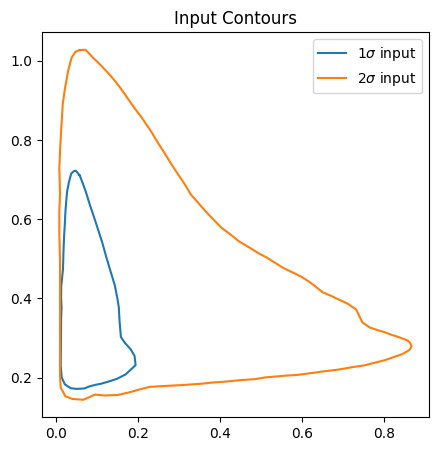

In [14]:
# ROI bounds (normalized)
x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0

# Load published CSV files of contour points
one_sigma_contour = np.loadtxt(
    f"../diamx/data/{experiment}_{bkg}_1sigma.csv", delimiter=","
)
two_sigma_contour = np.loadtxt(
    f"../diamx/data/{experiment}_{bkg}_2sigma.csv", delimiter=","
)
# Normalize cS1 and log(cS2)
if experiment == "xenonnt_sr1b" or experiment == "xenonnt_sr0":
    one_sigma_contour[:, 0] = one_sigma_contour[:, 0] / 100.0
    one_sigma_contour[:, 1] = np.log10(one_sigma_contour[:, 1]) / 2 - 1.05
    two_sigma_contour[:, 0] = two_sigma_contour[:, 0] / 100.0
    two_sigma_contour[:, 1] = np.log10(two_sigma_contour[:, 1]) / 2 - 1.05
elif experiment == "lz_ws2024":
    one_sigma_contour[:, 0] = (one_sigma_contour[:, 0] - 3) / (80 - 3)
    one_sigma_contour[:, 1] = (one_sigma_contour[:, 1] - 2.6) / (4.5 - 2.6)
    two_sigma_contour[:, 0] = (two_sigma_contour[:, 0] - 3) / (80 - 3)
    two_sigma_contour[:, 1] = (two_sigma_contour[:, 1] - 2.6) / (4.5 - 2.6)

# Build Shapely polygons (must be ordered CCW or CW)
poly1 = Polygon(one_sigma_contour)
poly2 = Polygon(two_sigma_contour)

# Plot to verify
plt.figure(figsize=(5, 5))
plt.plot(*poly1.exterior.xy, label=r"1$\sigma$ input")
plt.plot(*poly2.exterior.xy, label=r"2$\sigma$ input")
plt.legend()
plt.title("Input Contours")
plt.show()

## Peak point **A**
Choose a location inside $\Sigma_1$ to make the template look nice.

In [15]:
# Example peak location (normalized)
if experiment == "xenonnt_sr0":
    if bkg == "ac":
        A = np.array([0.03, 0.22])
    else:
        A = np.array([0.9, 0.25])
if experiment == "xenonnt_sr1b":
    A = np.array([0.017, 0.4])  # adjust as needed
elif experiment == "lz_ws2024":
    A = np.array([0.02, 0.3])

## Compute ray lengths $R_1(\phi)$, $R_2(\phi)$
For each angle $\phi$, cast a ray from **A** and find intersection distance to the polygon boundary.

In [16]:
n_phi = 3600
phis = np.linspace(0, 2 * np.pi, n_phi, endpoint=False)
ray_len = 2.0 * np.hypot(x_max - x_min, y_max - y_min)


def min_dist(inter):
    if inter.is_empty:
        return np.nan
    pts = []
    if inter.geom_type == "Point":
        pts = [inter]
    elif inter.geom_type in ("MultiPoint", "GeometryCollection"):
        pts = [g for g in inter.geoms if hasattr(g, "coords")]
    elif inter.geom_type == "LineString":
        pts = [Point(c) for c in inter.coords]
    ds = [Point(A).distance(p) for p in pts]
    ds = [d for d in ds if d > 1e-6]
    return min(ds) if ds else np.nan


R1 = np.array(
    [
        min_dist(
            LineString(
                [tuple(A), tuple(A + ray_len * np.array([np.cos(phi), np.sin(phi)]))]
            ).intersection(poly1.boundary)
        )
        for phi in phis
    ]
)
R2 = np.array(
    [
        min_dist(
            LineString(
                [tuple(A), tuple(A + ray_len * np.array([np.cos(phi), np.sin(phi)]))]
            ).intersection(poly2.boundary)
        )
        for phi in phis
    ]
)

## Solve for profile coefficients $a(\phi)$, $b(\phi)$
We enforce:
$$
f(R_1(\phi),\phi)=C_1,\quad f(R_2(\phi),\phi)=C_2,
 \quad f(r,\phi)=e^{-a(\phi)r² - b(\phi)r}.
$$

In [17]:
def solve_ab(C1, C2):
    u1, u2 = -np.log(C1), -np.log(C2)
    a_arr = np.zeros(n_phi)
    b_arr = np.zeros(n_phi)
    for i, (r1, r2) in enumerate(zip(R1, R2)):
        a_arr[i], b_arr[i] = np.linalg.solve([[r1**2, r1], [r2**2, r2]], [u1, u2])
    return a_arr, b_arr

## PDF evaluator **pdf_xy(x,y)**
Interpolates $a(\phi)$, $b(\phi)$ for arbitrary $(x,y)$ and returns $e^{-a r² - b r}$.

In [18]:
def pdf_xy(pt, a_arr, b_arr):
    dx, dy = pt - A
    phi = np.arctan2(dy, dx) % (2 * np.pi)
    r = np.hypot(dx, dy)
    # locate angle indices for interpolation
    idx = np.searchsorted(phis, phi) % n_phi
    i0, i1 = (idx - 1) % n_phi, idx
    w = (phi - phis[i0]) / ((phis[i1] - phis[i0]) % (2 * np.pi))
    ai = a_arr[i0] * (1 - w) + a_arr[i1] * w
    bi = b_arr[i0] * (1 - w) + b_arr[i1] * w
    return np.exp(-ai * r * r - bi * r)

## Determine $C_1$, $C_2$ via quadrature
Use a fixed (x,y) grid, mask points inside $\Sigma_1$/$\Sigma_2$, and solve
$\int_{\Sigma_1}f = 0.68, \; \int_{\Sigma_2}f = 0.95$ with ``least_squares``.

In [19]:
# build quadrature grid and masks
nx, ny = 200, 100
xs = np.linspace(x_min, x_max, nx)
ys = np.linspace(y_min, y_max, ny)
dx, dy = xs[1] - xs[0], ys[1] - ys[0]
Xg, Yg = np.meshgrid(xs, ys)
pts = np.vstack([Xg.ravel(), Yg.ravel()]).T
mask1 = np.array([poly1.contains(Point(p)) for p in pts]).reshape(ny, nx)
mask2 = np.array([poly2.contains(Point(p)) for p in pts]).reshape(ny, nx)


def residuals_quad(logC):
    C1, C2 = np.exp(logC)
    a_arr, b_arr = solve_ab(C1, C2)
    F = np.array([pdf_xy(p, a_arr, b_arr) for p in pts]).reshape(ny, nx)
    norm = F.sum() * dx * dy
    I1 = (F * mask1).sum() * dx * dy / norm
    I2 = (F * mask2).sum() * dx * dy / norm
    return [I1 - 0.68, I2 - 0.95]


sol = least_squares(residuals_quad, x0=[-0.5, -1.0], bounds=([-10, -10], [0, 0]))
C1, C2 = np.exp(sol.x)
a_arr, b_arr = solve_ab(C1, C2)
print(f"Found C1={C1:.3f}, C2={C2:.3f}")

Found C1=0.693, C2=0.107


## Sample AC events and build weighted histogram
Draw uniform (x,y), weight by `pdf_xy`, then histogram.

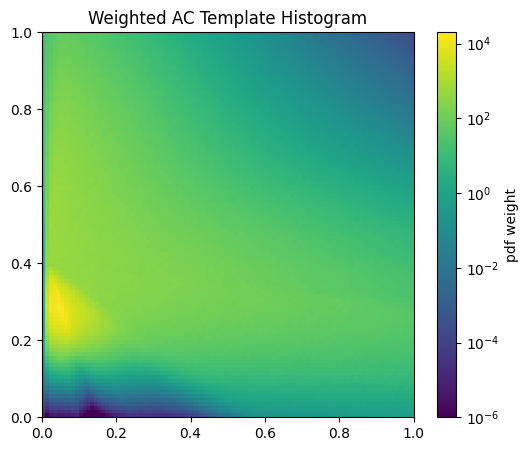

In [20]:
n_events = 5000000
events = np.zeros((n_events, 3))
for i in range(n_events):
    x = random.uniform(x_min, x_max)
    y = random.uniform(y_min, y_max)
    p = pdf_xy(np.array([x, y]), a_arr, b_arr)
    events[i] = (x, y, p)

hist, xedges, yedges = np.histogram2d(
    events[:, 0],
    events[:, 1],
    bins=100,
    range=[[x_min, x_max], [y_min, y_max]],
    weights=events[:, 2],
)
plt.figure(figsize=(6, 5))
plt.pcolormesh(xedges, yedges, hist.T, cmap="viridis", norm=LogNorm(vmin=1e-6))
plt.colorbar(label="pdf weight")
plt.title("Weighted AC Template Histogram")
plt.show()

## Compare derived vs input contours
Extract derived 68%/95% levels from weighted histogram and overlay.

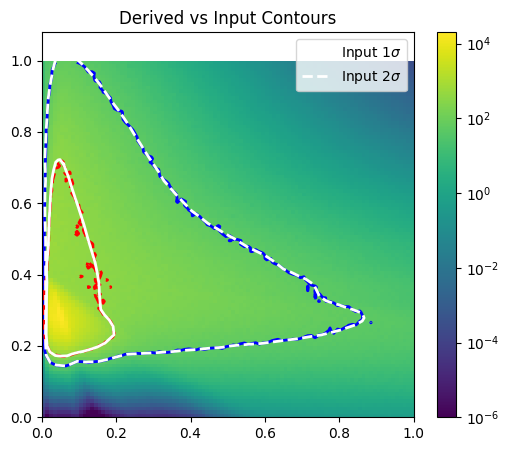

In [21]:
# compute contour levels
H_flat = hist.flatten()
idx = np.argsort(H_flat)[::-1]
H_sorted = H_flat[idx]
H_cum = np.cumsum(H_sorted) / H_sorted.sum()
lev68 = H_sorted[np.searchsorted(H_cum, 0.68)]
lev95 = H_sorted[np.searchsorted(H_cum, 0.95)]

fig, ax = plt.subplots(figsize=(6, 5))
xcenters, ycenters = 0.5 * (xedges[1:] + xedges[:-1]), 0.5 * (yedges[1:] + yedges[:-1])
Xg, Yg = np.meshgrid(xcenters, ycenters, indexing="ij")
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap="viridis", norm=LogNorm(1e-6))
ax.contour(
    Xg,
    Yg,
    hist,
    levels=[lev95, lev68],
    colors=["blue", "red"],
    linestyles=["-", "--"],
    linewidths=2,
)
ax.plot(*poly1.exterior.xy, color="white", linewidth=2, label=r"Input 1$\sigma$")
ax.plot(
    *poly2.exterior.xy,
    color="white",
    linestyle="--",
    linewidth=2,
    label=r"Input 2$\sigma$",
)
fig.colorbar(mesh, ax=ax)
ax.legend()
ax.set_title("Derived vs Input Contours")
plt.show()

## Save as diamx template
Convert weighted histogram into an HDF5 template.

In [22]:
if experiment == "xenonnt_sr0":
    mh = Histdd(
        events[:, 0] * 100,
        10 ** (events[:, 1] * 2 + 2.1),
        bins=[np.linspace(0, 100, 101), np.logspace(2.1, 4.1, 81)],
        weights=events[:, 2],
        axis_names=["cs1", "cs2"],
    )
    mh.histogram /= mh.histogram.sum()
    inference_interface.multihist_to_template(
        [mh],
        f"../diamx/data/{experiment}_{bkg}_template_contour_driven.h5",
        ["cs1-cs2"],
    )

elif experiment == "xenonnt_sr1b":
    mh = Histdd(
        events[:, 0] * 100,
        10 ** (events[:, 1] * 2 + 2.1),
        bins=[np.linspace(0, 100, 101), np.logspace(2.1, 4.1, 81)],
        weights=events[:, 2],
        axis_names=["cs1", "cs2"],
    )
    mh.histogram /= mh.histogram.sum()
    inference_interface.multihist_to_template(
        [mh],
        f"../diamx/data/{experiment}_{bkg}_template_contour_driven.h5",
        ["cs1-cs2"],
    )
else:
    mh = Histdd(
        events[:, 0] * 77 + 3,
        10 ** (events[:, 1] * (4.5 - 2.6) + 2.6),
        bins=[np.linspace(3, 80, 78), np.logspace(2.8095597146352675, 4.5, 81)],
        weights=events[:, 2],
        axis_names=["s1c", "s2c"],
    )
    mh.histogram /= mh.histogram.sum()
    # inference_interface.multihist_to_template(
    #     [mh], f"../diamx/data{experiment}_{bkg}_template_contour_driven.h5", ["s1c-s2c"]
    # )